In [1]:
import muspan as ms
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pickle
import networkx as nx
import cv2

from roifile import roiread

print("Packages loaded successfully!")

Packages loaded successfully!


In [2]:
rois = roiread('data/hh5RoiSet.zip')
domain = ms.domain("test_domain")
n_limit = 10000
n=0
for i in rois:
    if n<n_limit:
        try:
            coords = i.coordinates()
            shape = [4806,5288] + [1,-1] * (coords + np.roll(coords,1,axis=0) + np.roll(coords,-1,axis=0) + np.roll(coords,-2,axis=0) + np.roll(coords,2,axis=0))/5
            #shape = [4806,5288] + [1,-1] * coords 
            domain.add_shapes([shape],"normal")    

        except Exception as e:
            print(e)
            print(i.coordinates())
        n=n+1
    

(<Figure size 1000x800 with 2 Axes>, <Axes: >)

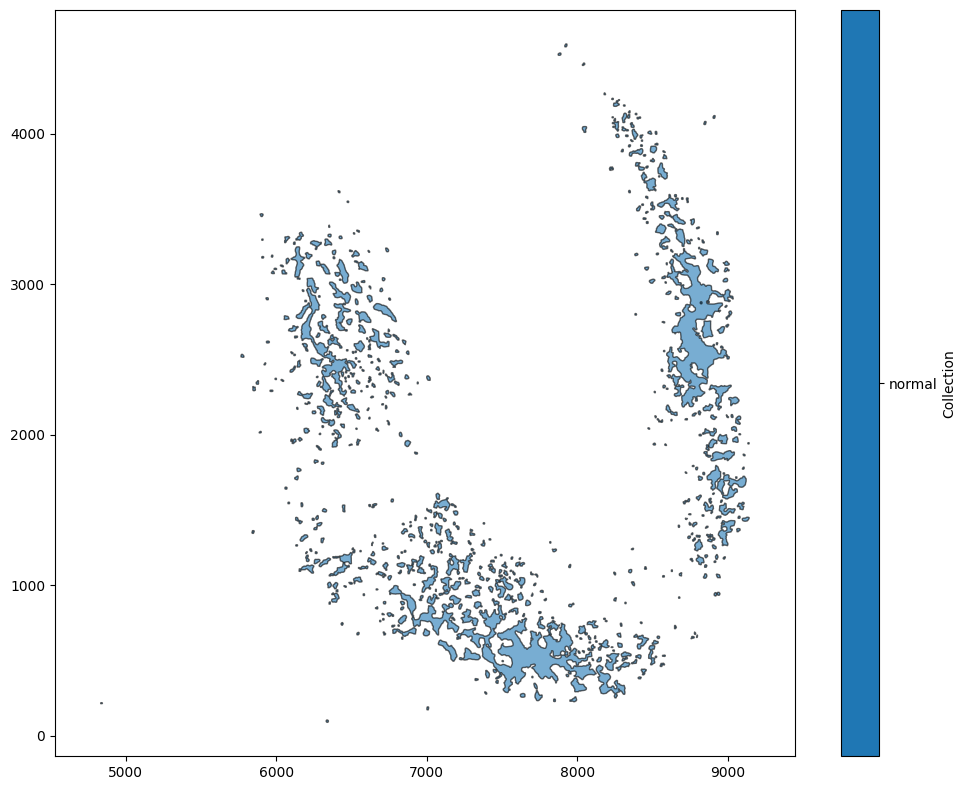

In [3]:
ms.visualise.visualise(domain)

In [4]:
test = ms.query.query(domain,("collection",),"is","normal")
circle = ms.geometry.circularity(domain,population=test)
disp_domain = ms.domain("disp_domain")

for i in range(len(circle[0])):
    if circle[0][i]<0.5:
        #print(i)
        disp_domain.add_shapes([shape],"low circularity")    
        domain.add_objects_to_collection(add_collection_to=i, collection_name="low circularity")#,color="red")

(<Figure size 1000x800 with 2 Axes>, <Axes: >)

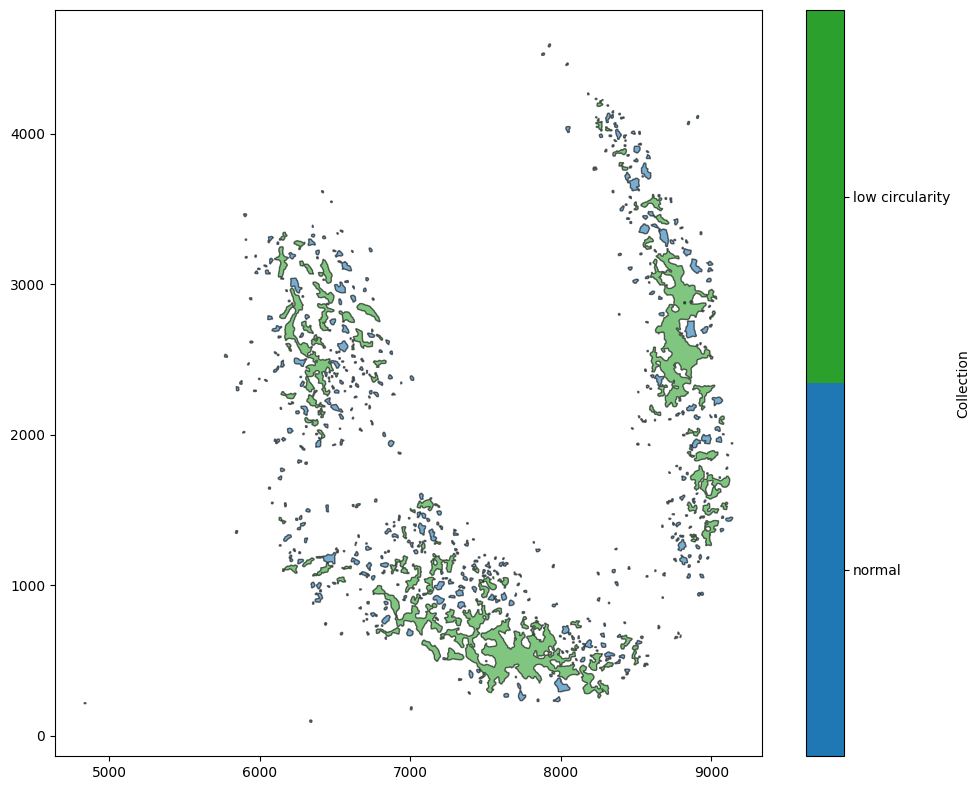

In [6]:
ms.visualise.visualise(domain)#,color_by="collection")